In [44]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from data.data_processor import DataProcessor
from data.splitter import SurvivalSplitter
from models.cox_model import CoxModel
from metrics.ibs import IBSMetric
from metrics.ibs_remain import IBSRemainMetric
from metrics.auprc import AUPRCMetric
from pipeline.evaluator import SurvivalEvaluator
from survivors.constants import get_y

In [45]:
processor = DataProcessor("data/individual_custody_timeline_rfm.csv")
cox_df = processor.load_and_prepare()
cox_df.head()

,name,episode_col,entry,dur,event,age,curr_dur_custody
0,aajah herrington,1,0.0,385.0,0,23,1.0
1,aaron aprile,1,0.0,55.0,0,27,55.0
2,aaron davis,1,0.0,432.0,0,41,118.0
3,aaron eddins,1,0.0,104.0,0,37,0.0
4,aaron epstein,1,0.0,297.0,1,22,1.0


In [46]:
splitter = SurvivalSplitter(test_size=0.2)
train_df, test_df = splitter.split_by_individual(cox_df)
train_df = train_df.drop(columns=["curr_dur_custody"])
test_df = test_df.drop(columns=["curr_dur_custody"])

print("Train individuals:", train_df["name"].nunique())
print("Test individuals:", test_df["name"].nunique())

Train individuals: 3382
Test individuals: 845


In [47]:
train_df["time"] = train_df["entry"] + train_df["dur"]
test_df["time"] = test_df["entry"] + test_df["dur"]

train_cens = train_df["event"].astype(bool)
test_cens = test_df["event"].astype(bool)

survival_train = get_y(
    cens=train_cens,
    time=train_df["time"],
    competing=False
)

survival_test = get_y(
    cens=test_cens,
    time=test_df["time"],
    competing=False
)

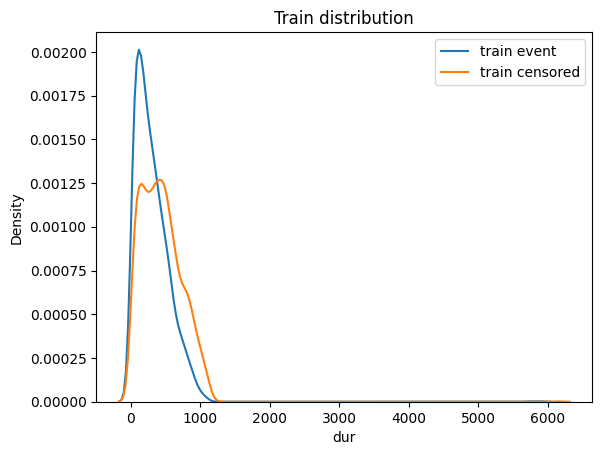

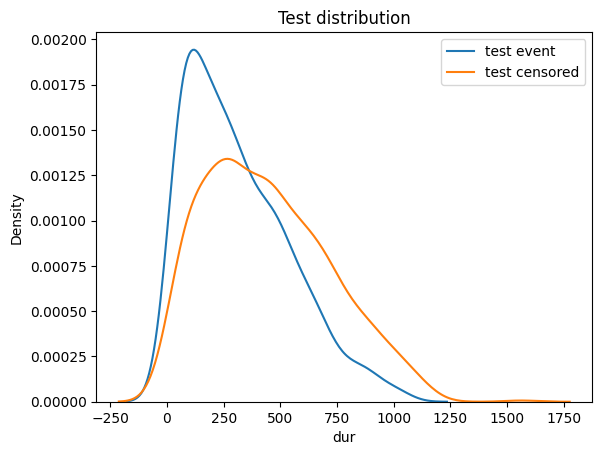

Train events: event
0    3382
1    2767
Name: count, dtype: int64
Test events: event
0    845
1    778
Name: count, dtype: int64


In [48]:
plt.figure()
sns.kdeplot(train_df[train_df["event"]==1]["dur"], label="train event")
sns.kdeplot(train_df[train_df["event"]==0]["dur"], label="train censored")
plt.legend()
plt.title("Train distribution")
plt.show()

plt.figure()
sns.kdeplot(test_df[test_df["event"]==1]["dur"], label="test event")
sns.kdeplot(test_df[test_df["event"]==0]["dur"], label="test censored")
plt.legend()
plt.title("Test distribution")
plt.show()

print("Train events:", train_df["event"].value_counts())
print("Test events:", test_df["event"].value_counts())


In [49]:
model = CoxModel(features=["age"])
model.fit(train_df)

In [50]:
#times = np.linspace(0, train_df["dur"].max(), 200)
horizon = np.quantile(train_df["dur"], 0.95)
times = np.linspace(0, horizon, 200)

test_features = test_df.drop(columns=["time", "event"])
predictions = model.predict_survival(test_features, times)
#predictions = model.predict_survival(test_df, times)
estimate = predictions.values

print("Estimate shape:", estimate.shape)
print("Test size:", len(test_df))

ibs_metric = IBSMetric()
mean_ibs, ibs_by_time = ibs_metric.compute(
    survival_train,
    survival_test,
    estimate,
    times
)

mean_ibs

Estimate shape: (1623, 200)
Test size: 1623


np.float64(0.041096877552936305)

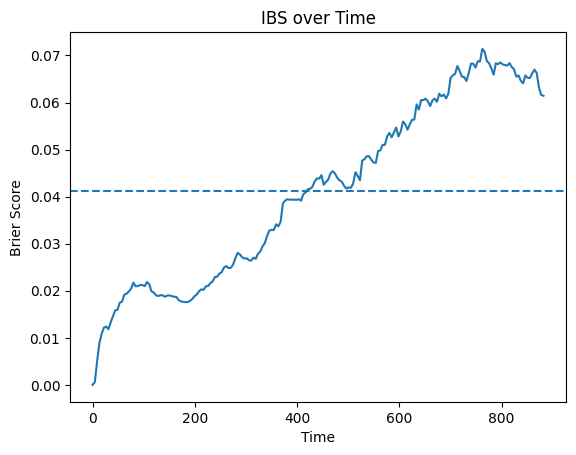

In [51]:
plt.plot(times, ibs_by_time)
plt.axhline(y=mean_ibs, linestyle="--")
plt.title("IBS over Time")
plt.xlabel("Time")
plt.ylabel("Brier Score")
plt.show()